In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import run_fair

import utils_MLP

import seaborn as sns
from cmcrameri import cm

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

## 1. Create CO2 + CH4 scenarios

In [8]:
# Required parameters
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)

emis_dict_train = run_fair.load_cmip7_extensions(n_steps, ['CO2','CH4'])

# Idealized step (similar to 4xCO2)
zero_emis = np.zeros(n_steps)
step = np.zeros(n_steps)
year_step = 50
step[year_step:] = 10 # Step magnitude

# CO2-only
emis_dict_train['step_CO2'] = run_fair.ensure_all_agents({'CO2': step, 'CH4':zero_emis}, n_steps)

# CH4-only
emis_dict_train['step_CH4'] = run_fair.ensure_all_agents({'CO2': zero_emis, 'CH4':100*step}, n_steps)

# Idealized pulse
pulse_co2, pulse_ch4 = np.zeros(n_steps), np.zeros(n_steps)
pulse_co2[0] = 5000 # Pulse magnitude
pulse_ch4[100] = 5000
emis_dict_train['pulse'] = run_fair.ensure_all_agents({'CO2': pulse_co2, 'CH4':pulse_ch4}, n_steps)

# Idealized step (similar to 4xCO2)
step_co2, step_ch4 = np.zeros(n_steps), np.zeros(n_steps)
year_step = 50
step_co2[year_step:] = 10 # Step magnitude
step_ch4[2*year_step:] = 10 # Step magnitude
emis_dict_train['step'] = run_fair.ensure_all_agents({'CO2': step_co2, 'CH4':step_ch4}, n_steps)

# Sinusoid
t = np.arange(n_steps)
amplitude = 39.741618
frequency = 0.002614
sine_co2 = amplitude * np.sin(2 * np.pi * frequency * t)
sine_ch4 = 10 * amplitude * np.sin(2 * 2 * np.pi * frequency * t)
emis_dict_train['sine'] = run_fair.ensure_all_agents({'CO2': sine_co2, 'CH4':sine_ch4}, n_steps)

# Noise
sigma = 100 # Noise standard deviation
n = 2
u = utils_MLP.generate_uncorrelated_signals(n, n_steps)
utils_MLP.verify(u)
noise_co2, noise_ch4 = u
emis_dict_train['noise'] = run_fair.ensure_all_agents({'CO2': sigma*noise_co2, 'CH4': sigma*noise_ch4}, n_steps)

scenarios_all = list(emis_dict_train.keys())


Verifying Correlation (dot products of e_i, e_j for i!=j should be close to 0.0):
  <e_1, e_2>: -0.000000


In [9]:
nan_force = np.zeros(n_steps)
delT_train_dict = {}
agents = ['CO2','CH4','N2O','Sulfur','BC']
agents_lim = ['CO2','CH4']

for scen in scenarios_all:
  f = run_fair.build_fair(start, stop, input_mode="emissions")
  emis = {a: nan_force for a in agents}

  for agent in agents_lim:
    emis[agent] = emis_dict_train[scen][agent]

  run_fair.reset_state(f)
  run_fair.set_emissions(f, years, emis)
  _, T, T_mean, _ = run_fair.run_fair(f, years)
  delT_train_dict[scen] = T_mean

/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:251: RuntimeWarning: invalid value encountered in sqrt
  (a3 * np.sqrt(ch4) + b3 * np.sqrt(n2o) + d3)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:252: RuntimeWarning: invalid value encountered in sqrt
  * (np.sqrt(ch4) - np.sqrt(ch4_base))
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:257: RuntimeWarning: invalid value encountered in sqrt
  (a2 * np.sqrt(co2) + b2 * np.sqrt(n2o) + c2 * np.sqrt(ch4) + d2)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:251: RuntimeWarning: invalid value encountered in sqrt
  (a3 * np.sqrt(ch4) + b3 * np.sqrt(n2o) + d3)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:252: RuntimeWarning: invalid value encountered in sqrt
  * (np.sqrt(ch4) - np.sqrt(ch4_base))
/Users/chriswomack/anacond

Text(0.5, 0, 'Year')

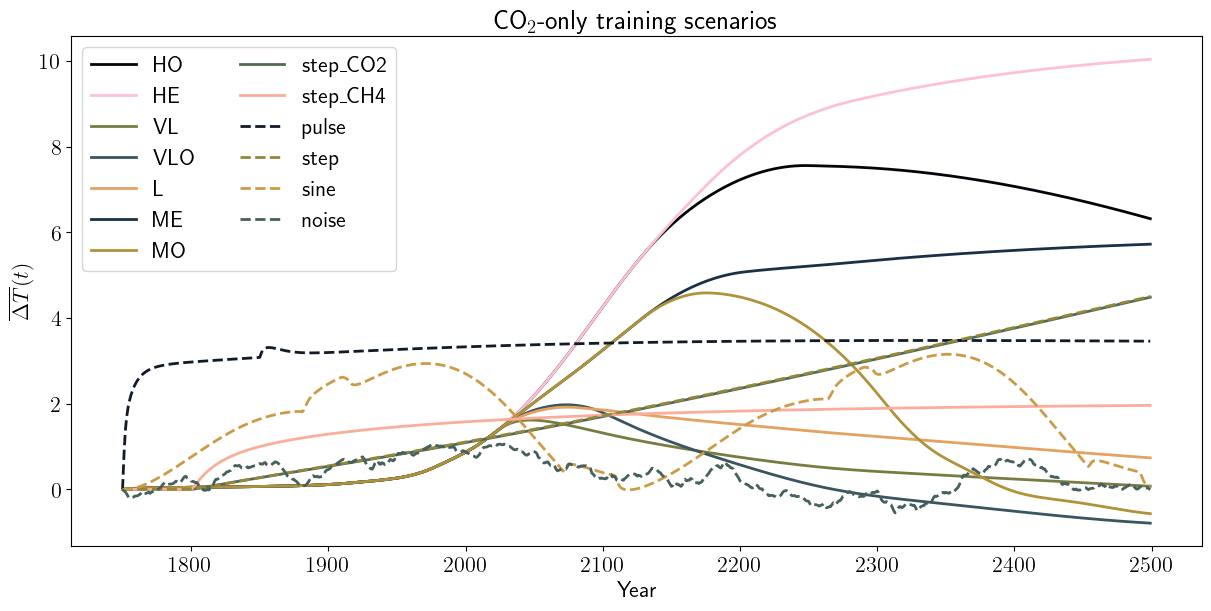

In [10]:
fig, ax = plt.subplots(figsize=(12,6), constrained_layout=True)
for i, scen in enumerate(scenarios_all):
  if scen in ['pulse','step','sine','noise']:
    ls = '--'
  else:
    ls = '-'
  ax.plot(years, delT_train_dict[scen], label=scen, ls=ls, lw=2, c=cm.batlowKS(i))
ax.legend(loc='upper left', ncol=2)
ax.set_title(r'CO$_2$-only training scenarios')
ax.set_ylabel(r'$\overline{\Delta T}(t)$')
ax.set_xlabel('Year')

In [11]:
all_series = []
for scen in scenarios_all:
  all_series.append((emis_dict_train[scen], delT_train_dict[scen]))

agents = ['CO2','CH4']
error_dict_single, yhat_dict_single = utils_MLP.evaluate_trainsets_vs_tests(scenarios_all, all_series, scenarios_all, all_series, agents, n_lags=10, random_state=0)

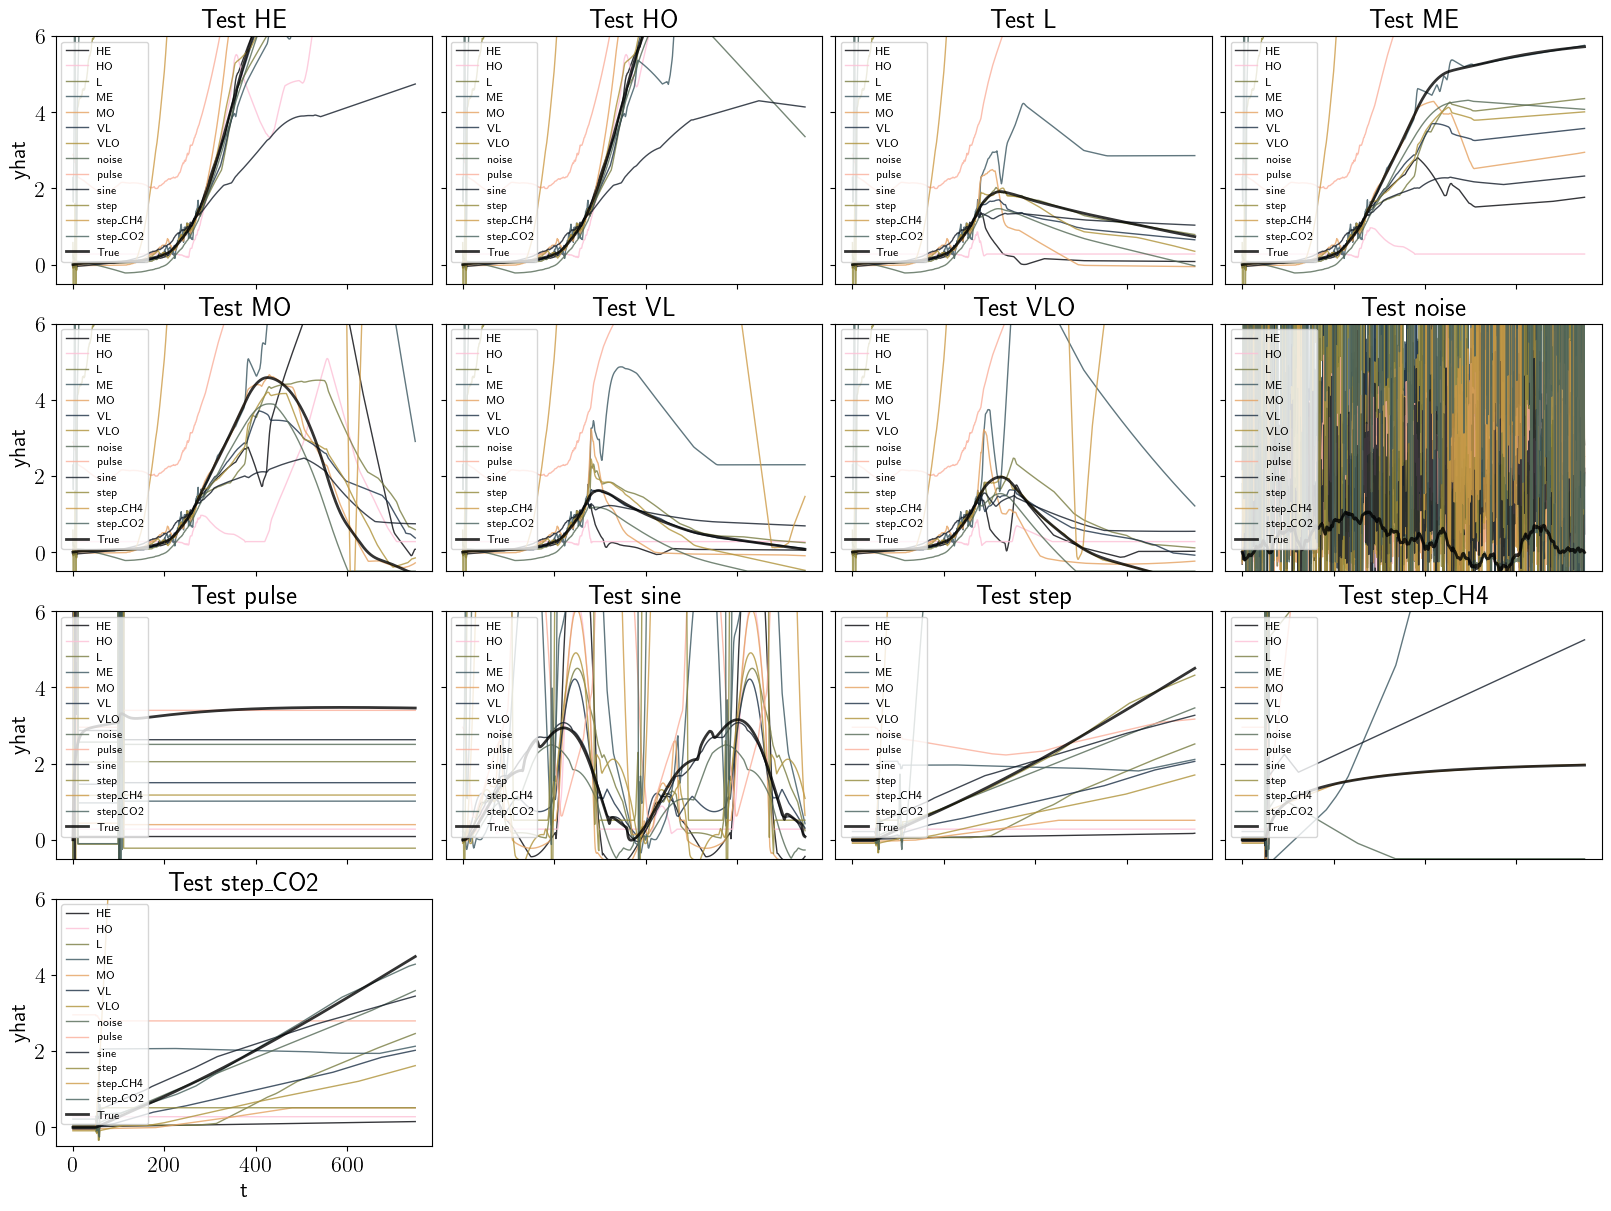

In [12]:
utils_MLP.plot_yhats_grid(error_dict_single, yhat_dict_single, delT_train_dict)

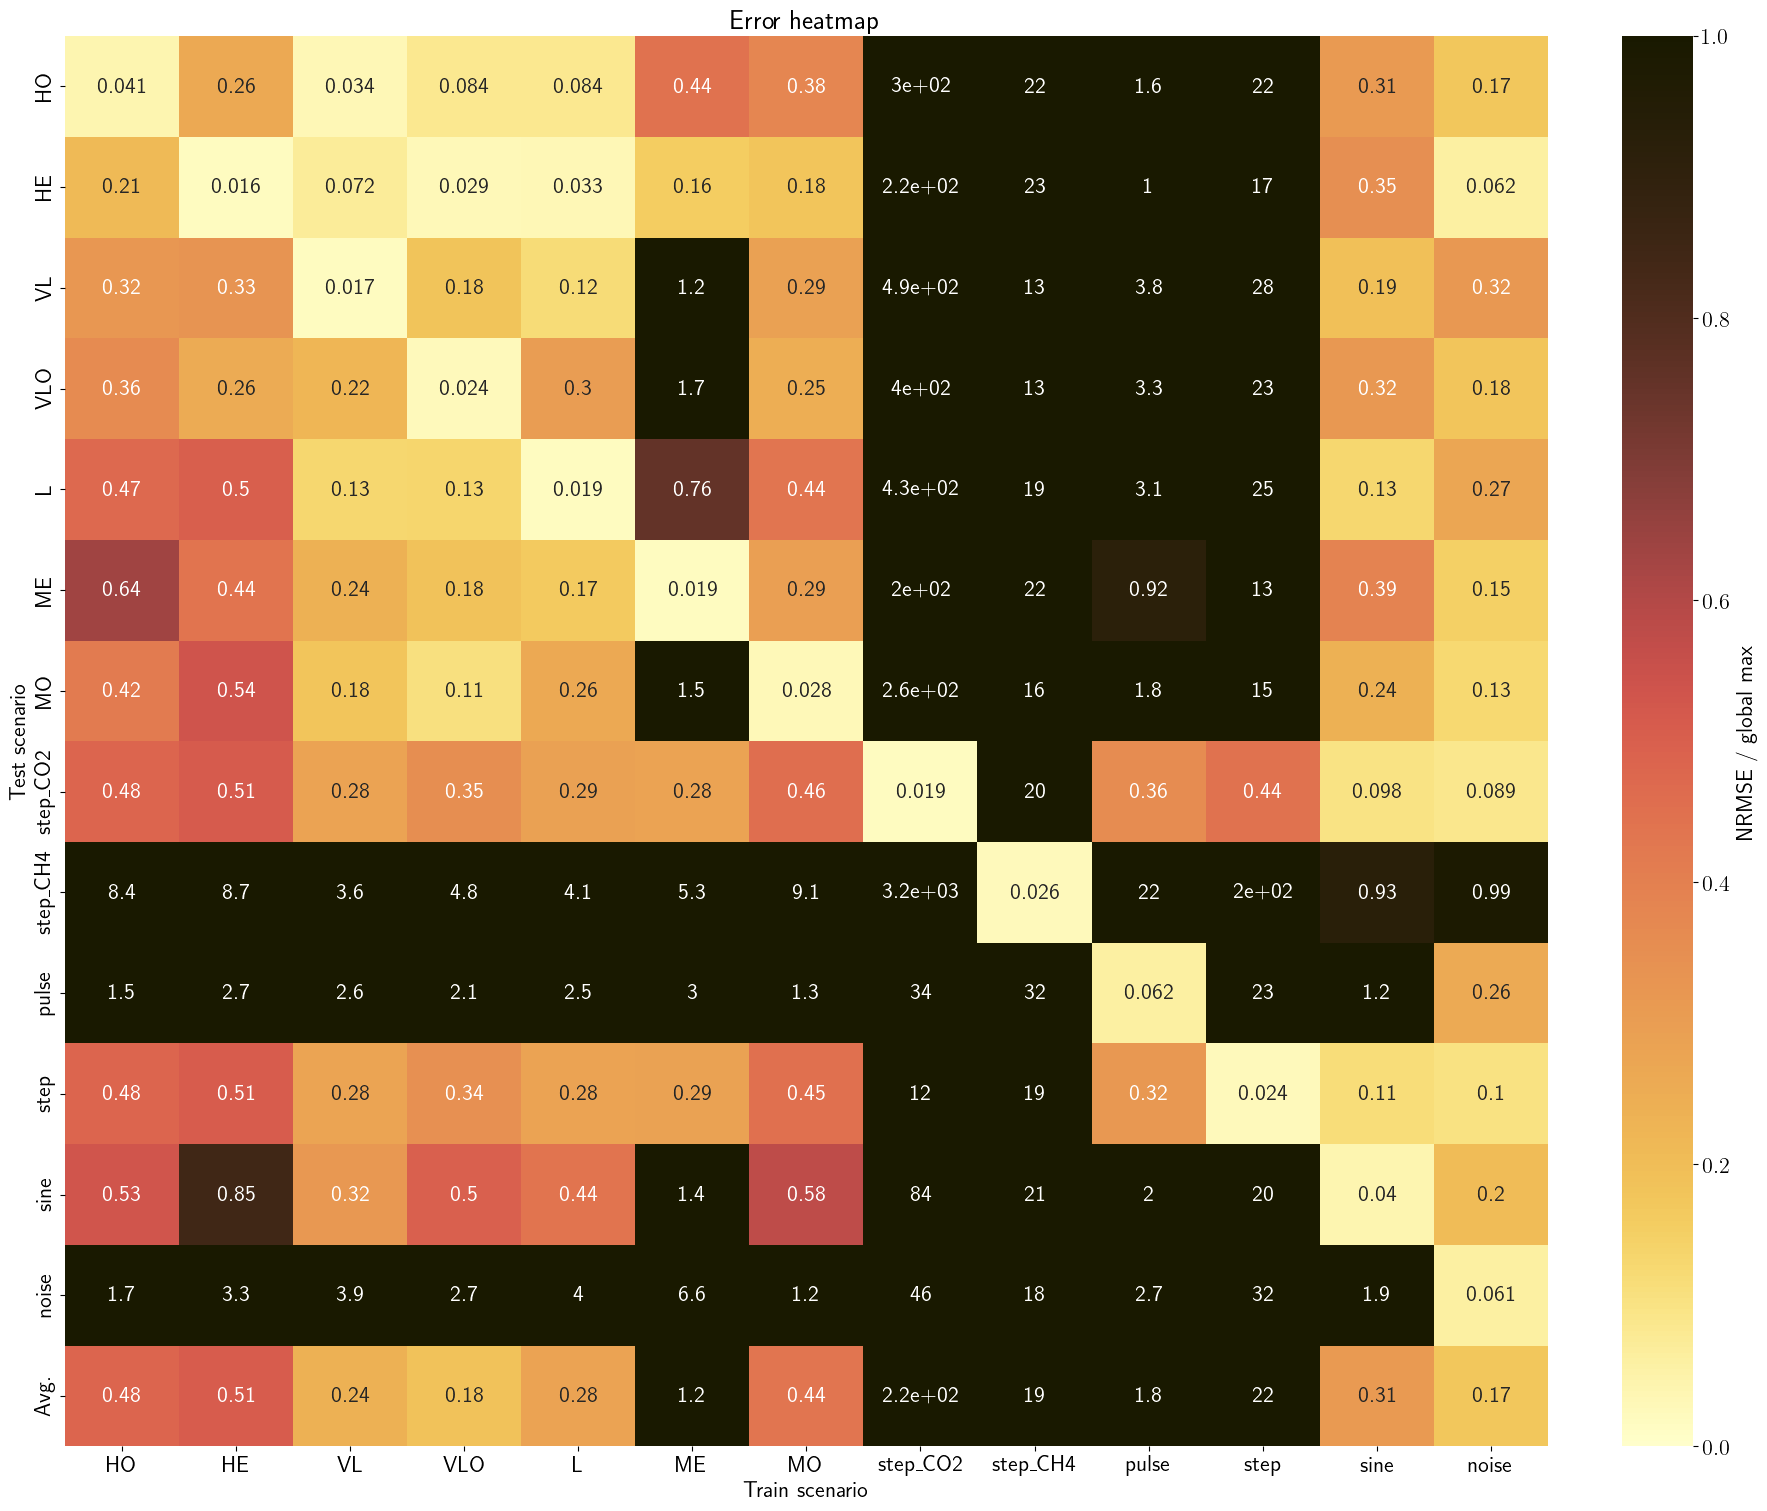

In [13]:
scenarios_test = list(emis_dict_train.keys())
utils_MLP.plot_error_heatmap(error_dict_single, scenarios_test, scenarios_test)

In [14]:
CMIP7 = ['HO','HE','VL','VLO','L','ME','MO']
training_groups = {'Bracket':['HE','VL']}
training_groups['All_CMIP7'] = CMIP7

for scen in CMIP7:
  key = f'Hold_{scen}'
  value = [tag for tag in CMIP7 if tag != scen]
  training_groups[key] = value

#training_groups['Optimal'] = ['Optimal']

error_dict_multi, yhat_dict_multi = utils_MLP.evaluate_trainsets_vs_tests(scenarios_all, all_series, scenarios_all, all_series, training_groups=training_groups, n_lags=10, random_state=0)

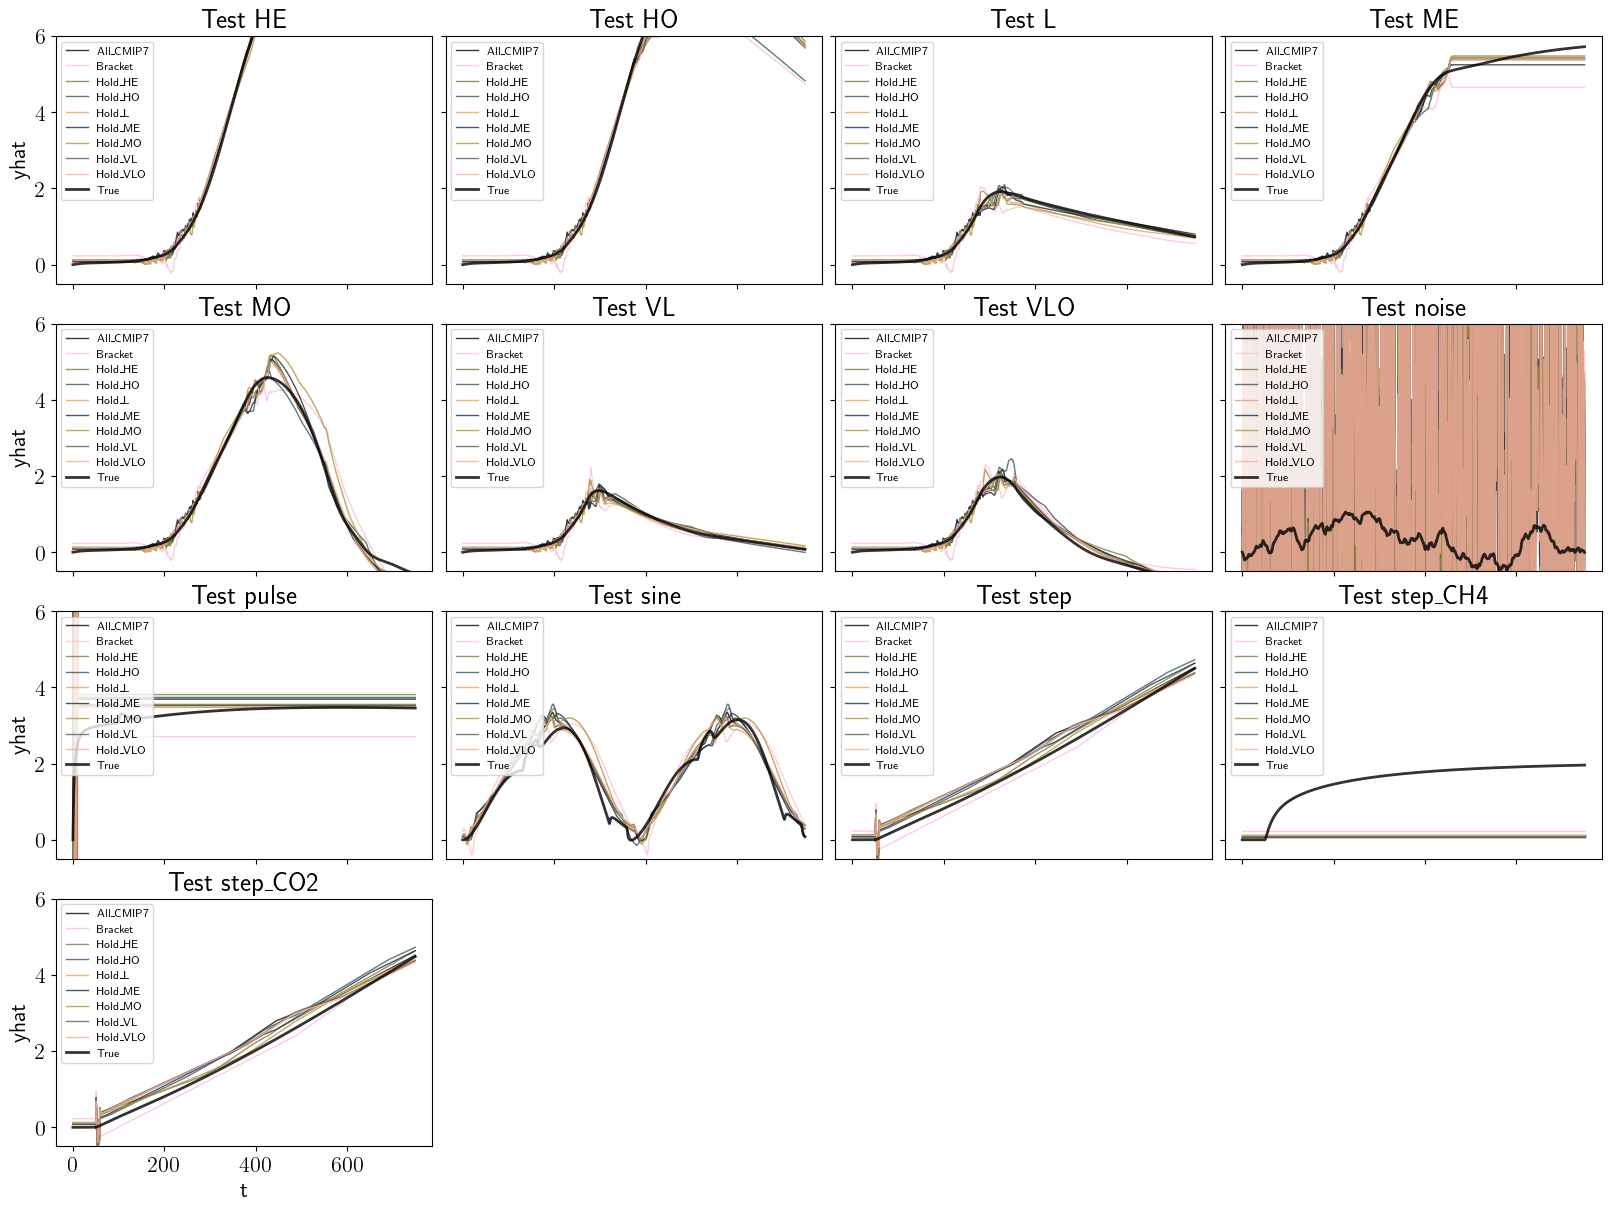

In [15]:
utils_MLP.plot_yhats_grid(error_dict_multi, yhat_dict_multi, delT_train_dict)

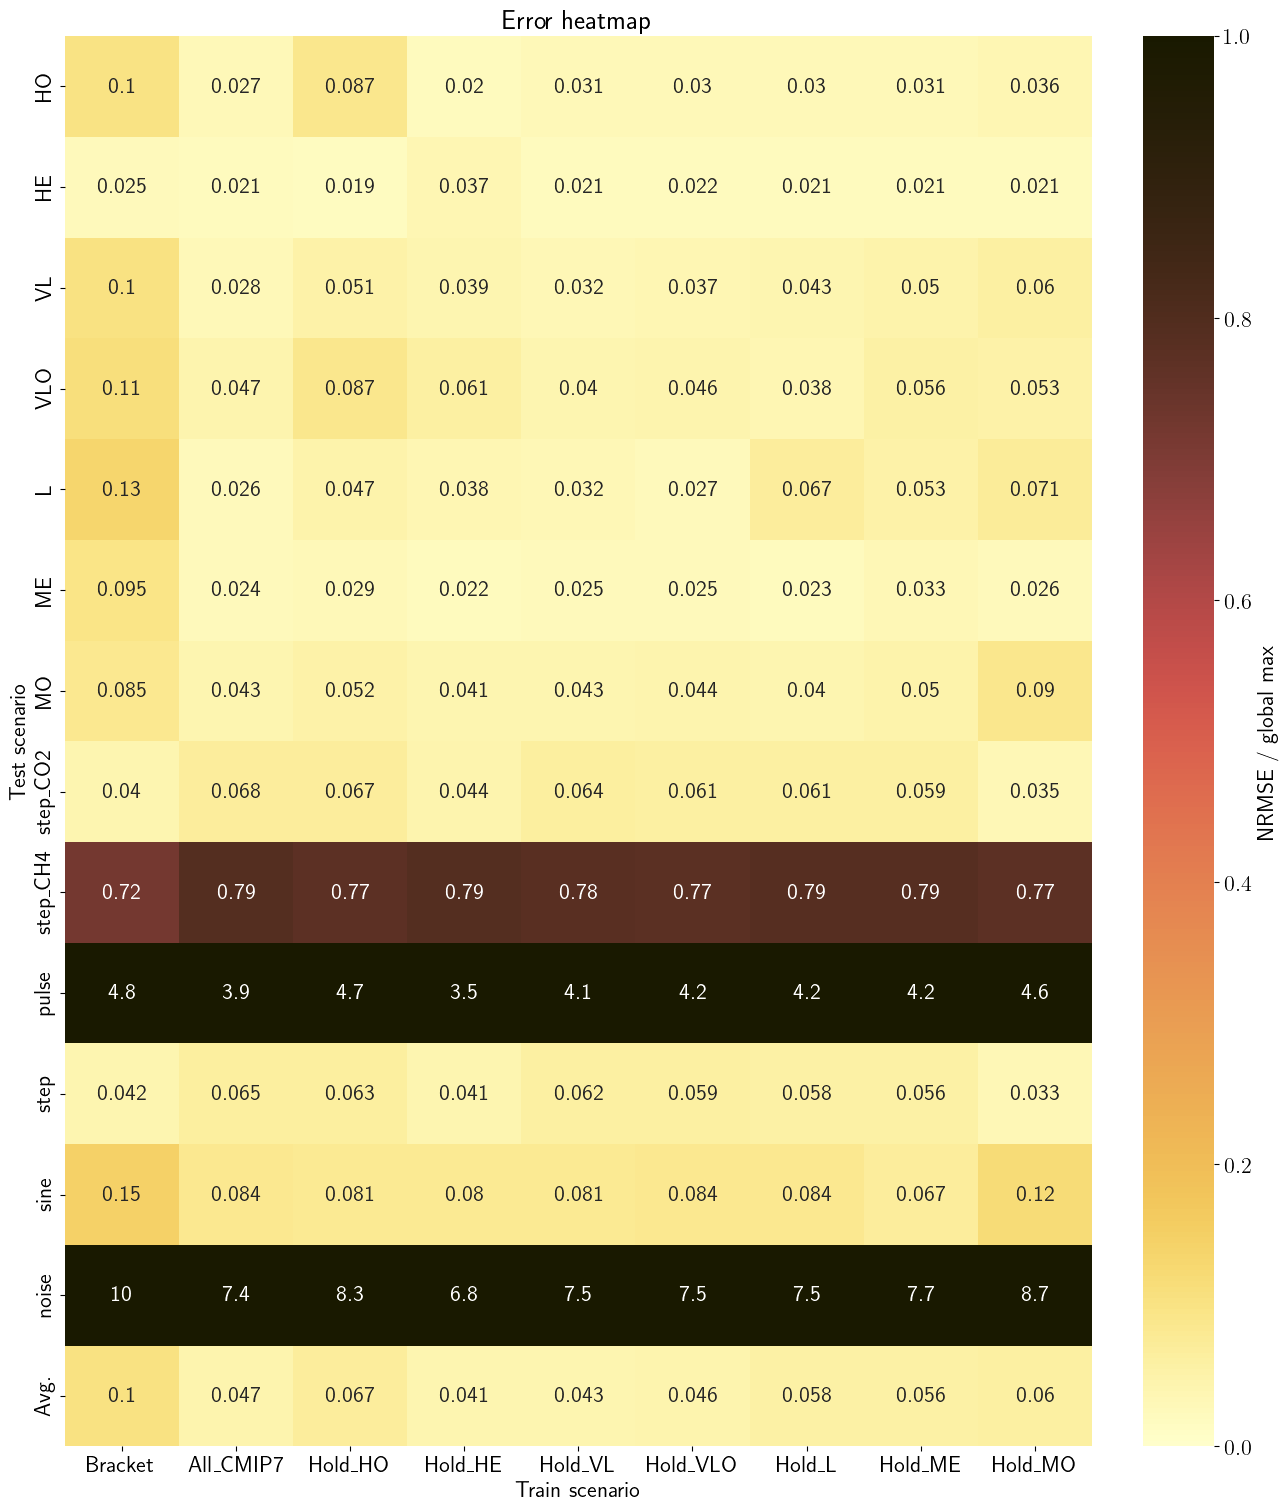

In [16]:
scenarios_test = list(emis_dict_train.keys())
scenarios_train = list(training_groups.keys())
utils_MLP.plot_error_heatmap(error_dict_multi, scenarios_train, scenarios_test)